# Etapa 0

Carregamento de bibliotecas

In [20]:
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np
from pathlib import Path

# Etapa 1

Foram coletadas 6 imagens em resolução 4032x3024. Para melhor performance, as imagens serão redimensionadas com o fator x0.25, utilizando Lanczos.

## Redimensionamento

In [21]:
from src.resize import resize_images

images_raw_dir = Path("./data/raw/")
images_processed_dir = Path("./data/processed")

resize_images(images_raw_dir, images_processed_dir, 0.25)

IMG_0118.JPG: 3024x4032 -> 756x1008
IMG_0119.JPG: 3024x4032 -> 756x1008
IMG_0120.JPG: 3024x4032 -> 756x1008


## Carregregamento das imagens

In [22]:
def plot_image_grid(images, title="Imagens"):
    fig, axes = plt.subplots(1, 3, figsize=(10, 6))
    fig.suptitle(title)
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        ax.axis('off')
        ax.set_title(f'Imagem {i+1}')

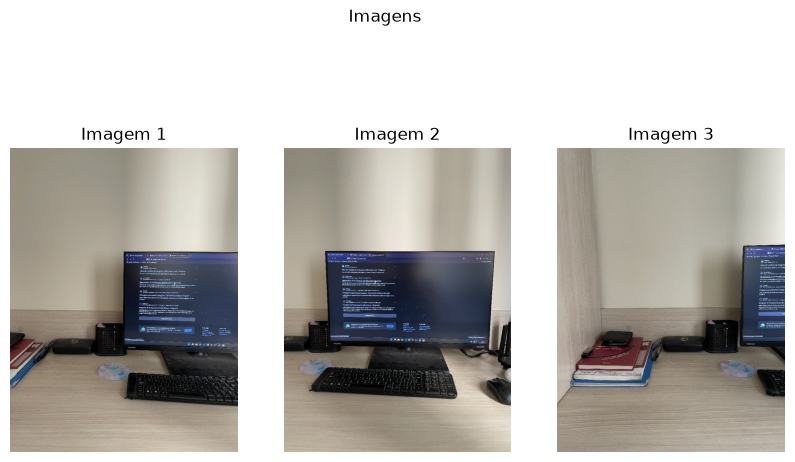

In [23]:
images = []
for image_path in sorted(images_processed_dir.iterdir()):
    image = cv2.imread(image_path)
    images.append(image)

random.shuffle(images)
plot_image_grid(images)

# Etapa 2

Detecção de keypoints com SIFT e ORB

In [24]:
from src.features import detect_sift, detect_orb

def draw_keypoints(images, method="sift"):
    images_with_keypoints = []
    if method.lower() == "sift":
        detector = detect_sift
    elif method.lower() == "orb":
        detector = detect_orb

    print(f"Detector: {method}")
    for image in images:
        keypoints, descriptors = detector(image)
        print("Número de keypoints:", len(keypoints))
        print("Formato dos descritores:", descriptors.shape)

        image_keypoints = cv2.drawKeypoints(
            image,
            keypoints,
            None,
            color=(0, 255, 0),
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
        )

        images_with_keypoints.append({
            "image": image_keypoints,
            "keypoints": keypoints,
            "descriptors": descriptors
        })

    return images_with_keypoints

Detector: sift
Número de keypoints: 908
Formato dos descritores: (908, 128)
Número de keypoints: 1010
Formato dos descritores: (1010, 128)
Número de keypoints: 724
Formato dos descritores: (724, 128)


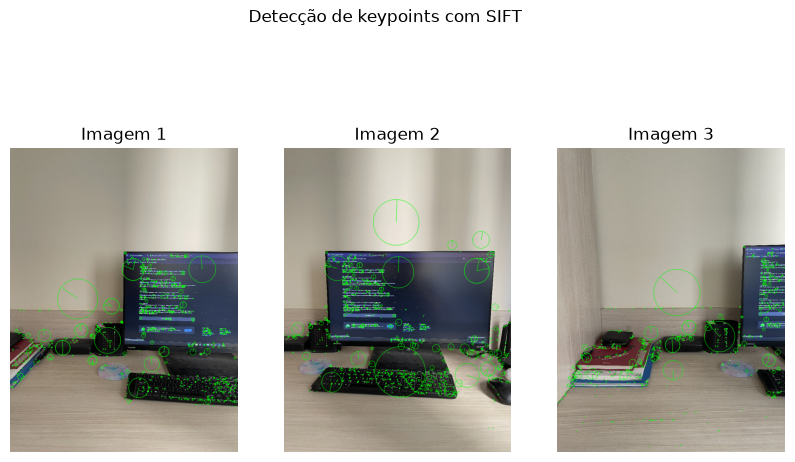

In [25]:
images_sift = draw_keypoints(images, "sift")
plot_image_grid([item["image"] for item in images_sift], "Detecção de keypoints com SIFT")

Detector: orb
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)
Número de keypoints: 500
Formato dos descritores: (500, 32)


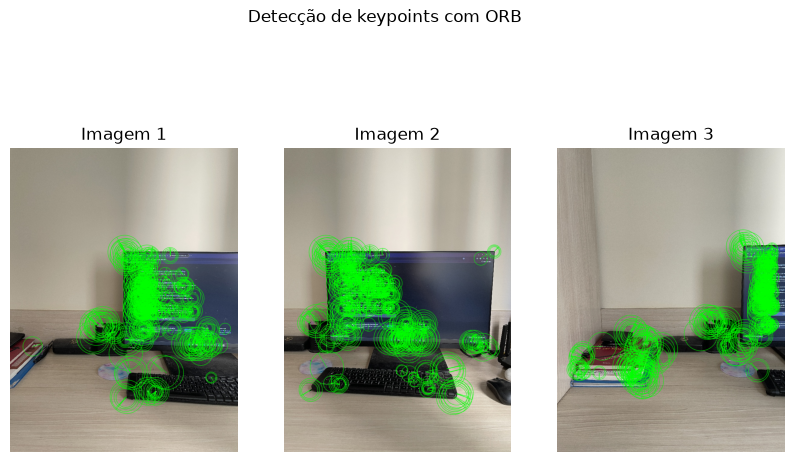

In [26]:
images_orb = draw_keypoints(images, "orb")
plot_image_grid([item["image"] for item in images_orb], "Detecção de keypoints com ORB")

# Etapa 3

In [27]:
from src.matching import match_all_images

RATIO_THRESHOLD = 0.75

matches_dict, lowe_matches_dict = match_all_images(
    [item["descriptors"] for item in images_sift],
    method="sift",
    ratio=RATIO_THRESHOLD
)

print("Before Lowe")
for (i, j), matches in matches_dict.items():
    print(
        f"Imagem {i} <-> Imagem {j}: "
        f"{len(matches)} matches"
    )

print("After Lowe")
for (i, j), matches in lowe_matches_dict.items():
    print(
        f"Imagem {i} <-> Imagem {j}: "
        f"{len(matches)} matches"
    )

Before Lowe
Imagem 0 <-> Imagem 1: 908 matches
Imagem 0 <-> Imagem 2: 908 matches
Imagem 1 <-> Imagem 2: 1010 matches
After Lowe
Imagem 0 <-> Imagem 1: 79 matches
Imagem 0 <-> Imagem 2: 64 matches
Imagem 1 <-> Imagem 2: 46 matches


In [28]:
def show_matches(
    image1,
    keypoints1,
    image2,
    keypoints2,
    matches,
    title=""
):
    result = cv2.drawMatches(
        image1,
        keypoints1,
        image2,
        keypoints2,
        matches,
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(18, 8))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(title)
    plt.show()

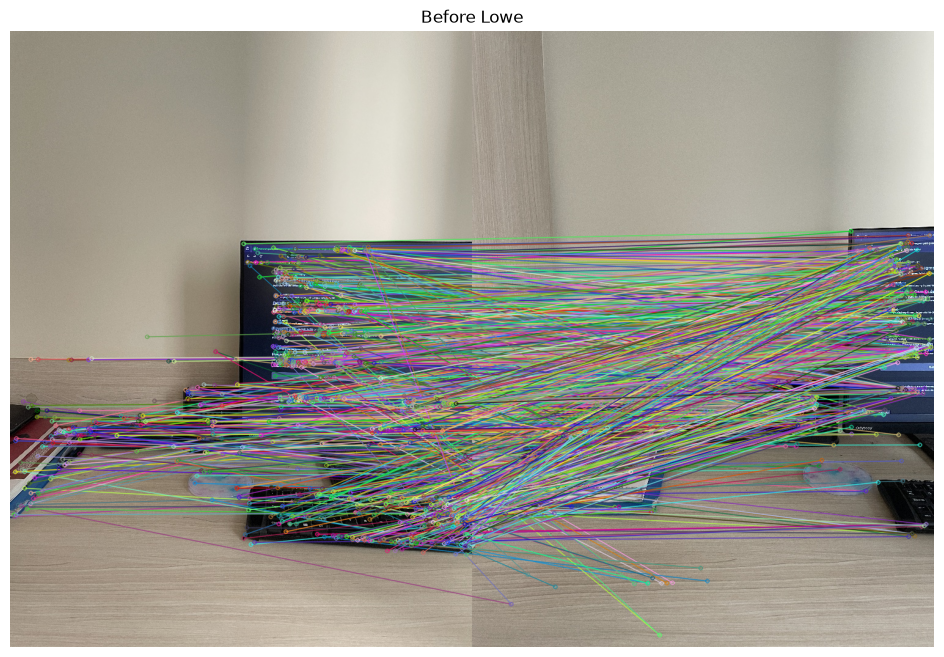

In [29]:
i = 0
j = 2

show_matches(images[i], 
            images_sift[i]["keypoints"],
            images[j], 
            images_sift[j]["keypoints"],
            matches_dict[(i, j)],
            "Before Lowe")

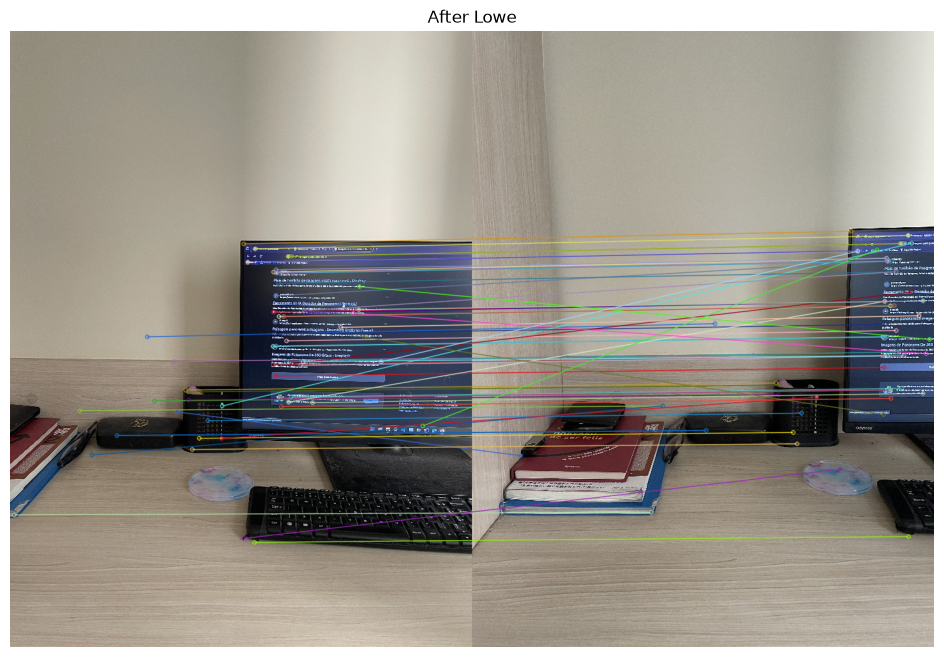

In [30]:
i = 0
j = 2

show_matches(images[i], 
            images_sift[i]["keypoints"],
            images[j], 
            images_sift[j]["keypoints"],
            lowe_matches_dict[(i, j)],
            "After Lowe")

# Etapa 4

Ordenação automática

In [31]:
from src.ordering import build_connectivity_matrix

connectivity_matrix = build_connectivity_matrix(lowe_matches_dict)

print(connectivity_matrix)

[[ 0 79 64]
 [79  0 46]
 [64 46  0]]


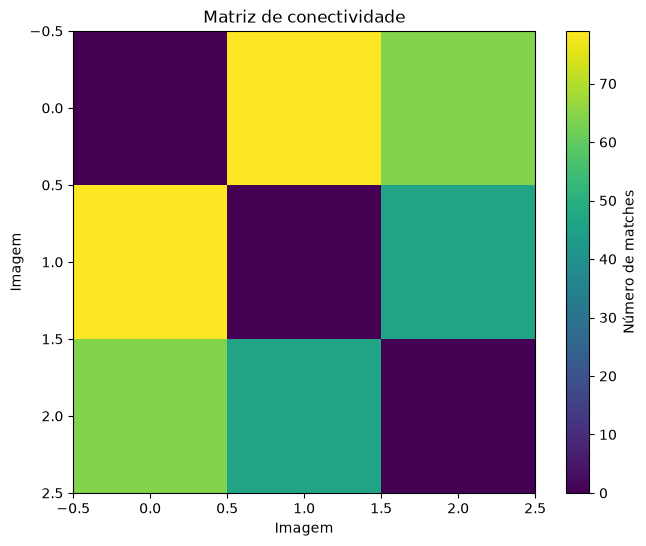

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(
    connectivity_matrix,
    cmap="viridis"
)

plt.colorbar(label="Número de matches")

plt.xlabel("Imagem")
plt.ylabel("Imagem")
plt.title("Matriz de conectividade")

plt.show()

In [33]:
from src.ordering import build_graph

graph = build_graph(
    connectivity_matrix,
    min_matches=25
)

print(graph)

{0: [1, 2], 1: [0, 2], 2: [0, 1]}


# Etapa 5

Homografia e Alinhamento

In [37]:
from src.homography import (
    estimate_homography,
    inlier_rate,
    reprojection_error
)

i = 0
j = 1

H, mask = estimate_homography(
    images_sift[i]["keypoints"],
    images_sift[j]["keypoints"],
    lowe_matches_dict[(i, j)]
)

rate = inlier_rate(mask)

error = reprojection_error(
    images_sift[i]["keypoints"],
    images_sift[j]["keypoints"],
    lowe_matches_dict[(i, j)],
    H,
    mask
)

print("Good matches:", len(lowe_matches_dict[(i, j)]))
print("Inliers:", int(mask.sum()) if mask is not None else 0)
print("Taxa de inliers:", rate)
print("Erro médio de reprojeção:", error)

Good matches: 79
Inliers: 37
Taxa de inliers: 0.46835443037974683
Erro médio de reprojeção: 0.9193949103355408


In [38]:
height1, width1 = images[i].shape[:2]
height2, width2 = images[j].shape[:2]

corners1 = np.float32([
    [0, 0],
    [width1, 0],
    [width1, height1],
    [0, height1]
]).reshape(-1, 1, 2)

corners2 = np.float32([
    [0, 0],
    [width2, 0],
    [width2, height2],
    [0, height2]
]).reshape(-1, 1, 2)

transformed_corners1 = cv2.perspectiveTransform(
    corners1,
    H
)

all_corners = np.concatenate([
    transformed_corners1,
    corners2
])

[x_min, y_min] = np.floor(
    all_corners.min(axis=0).ravel()
).astype(int)

[x_max, y_max] = np.ceil(
    all_corners.max(axis=0).ravel()
).astype(int)

translation = np.array([
    [1, 0, -x_min],
    [0, 1, -y_min],
    [0, 0, 1]
], dtype=np.float64)

canvas_width = x_max - x_min
canvas_height = y_max - y_min

# Etapa 6

Composição, Blending e Deghosting

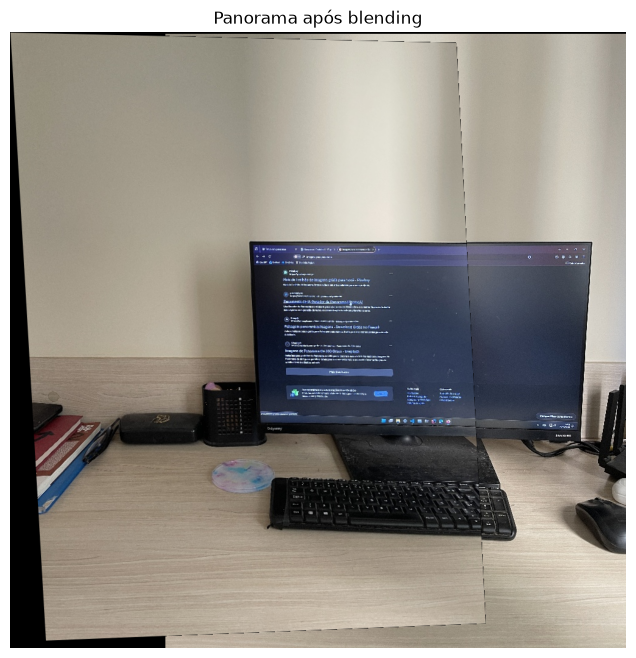

In [41]:
from src.blending import blend_images

warped1 = cv2.warpPerspective(
    images[i],
    translation @ H,
    (canvas_width, canvas_height)
)

warped2 = cv2.warpPerspective(
    images[j],
    translation,
    (canvas_width, canvas_height)
)

panorama = blend_images(warped1, warped2, 1)

plt.figure(figsize=(16, 8))

plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))

plt.axis("off")
plt.title("Panorama após blending")
plt.show()